In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/Daniel-UTEC/bermudez_daniel_2503162022/refs/heads/main/data/clave_A_correlacion.csv")

df.head()

,cliente_id,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
0,A-C0001,37,468,4,36.45,8.73,1,7,22.02,297.03
1,A-C0002,27,1076,8,63.31,9.15,0,6,24.89,524.34
2,A-C0003,19,948,5,44.25,8.33,0,1,26.58,181.14
3,A-C0004,41,832,8,63.11,9.90,0,5,16.22,532.66
4,A-C0005,30,1287,6,86.49,7.83,1,4,20.42,557.44


In [4]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221 entries, 0 to 220
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cliente_id          221 non-null    object 
 1   edad                221 non-null    int64  
 2   ingresos_mensuales  221 non-null    int64  
 3   frecuencia_compra   221 non-null    int64  
 4   ticket_promedio     220 non-null    float64
 5   satisfaccion        220 non-null    float64
 6   reclamos            221 non-null    int64  
 7   uso_app             221 non-null    int64  
 8   tiempo_respuesta    220 non-null    float64
 9   consumo_total       221 non-null    float64
dtypes: float64(4), int64(5), object(1)
memory usage: 17.4+ KB


In [5]:
df.isnull().sum()

,0
cliente_id,0
edad,0
ingresos_mensuales,0
frecuencia_compra,0
ticket_promedio,1
satisfaccion,1
reclamos,0
uso_app,0
tiempo_respuesta,1
consumo_total,0


In [6]:
df.duplicated().sum()

np.int64(1)

In [7]:
df[df.duplicated()]

,cliente_id,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
220,A-C0006,50,529,5,59.54,7.6,1,4,26.73,323.45


In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.describe()

,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
count,220.000000,220.000000,220.000000,219.000000,219.000000,220.000000,220.00000,219.000000,220.000000
mean,33.909091,855.345455,7.027273,55.167397,7.540137,1.559091,5.10000,21.956530,410.555591
std,10.001411,250.947845,3.050441,16.220072,1.163388,1.582195,1.93714,5.791125,175.852896
min,18.000000,300.000000,1.000000,14.660000,2.390000,0.000000,0.00000,9.260000,72.590000
25%,27.000000,693.500000,6.000000,42.645000,6.910000,1.000000,4.00000,17.700000,289.642500
50%,34.000000,855.000000,7.000000,55.490000,7.630000,1.000000,5.00000,21.590000,389.640000
75%,41.000000,1012.000000,8.000000,67.280000,8.315000,2.000000,6.00000,25.675000,504.695000
max,60.000000,1517.000000,27.000000,96.050000,9.900000,9.000000,10.00000,40.160000,1291.030000


In [16]:
variables_numericas = [
    "ingresos_mensuales",
    "frecuencia_compra",
    "ticket_promedio",
    "satisfaccion",
    "reclamos",
    "uso_app",
    "tiempo_respuesta",
    "consumo_total"
]
print("")
print("Revision de valores atipicos:")

for columna in variables_numericas:
    media = df[columna].mean()
    desviacion = df[columna].std()

    limite_inferior = media - 2 * desviacion
    limite_superior = media + 2 * desviacion

    atipicos = df[
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    ]

    print("Variable:", columna)
    print("Media:", round(media, 2))
    print("Desviacion estandar:", round(desviacion, 2))
    print("Limite inferior:", round(limite_inferior, 2))
    print("Limite superior:", round(limite_superior, 2))
    print("Cantidad de valores atipicos:", len(atipicos))



Revision de valores atipicos:
Variable: ingresos_mensuales
Media: 855.35
Desviacion estandar: 250.95
Limite inferior: 353.45
Limite superior: 1357.24
Cantidad de valores atipicos: 13
Variable: frecuencia_compra
Media: 7.03
Desviacion estandar: 3.05
Limite inferior: 0.93
Limite superior: 13.13
Cantidad de valores atipicos: 4
Variable: ticket_promedio
Media: 55.17
Desviacion estandar: 16.22
Limite inferior: 22.73
Limite superior: 87.61
Cantidad de valores atipicos: 11
Variable: satisfaccion
Media: 7.54
Desviacion estandar: 1.16
Limite inferior: 5.21
Limite superior: 9.87
Cantidad de valores atipicos: 11
Variable: reclamos
Media: 1.56
Desviacion estandar: 1.58
Limite inferior: -1.61
Limite superior: 4.72
Cantidad de valores atipicos: 11
Variable: uso_app
Media: 5.1
Desviacion estandar: 1.94
Limite inferior: 1.23
Limite superior: 8.97
Cantidad de valores atipicos: 13
Variable: tiempo_respuesta
Media: 21.96
Desviacion estandar: 5.79
Limite inferior: 10.37
Limite superior: 33.54
Cantidad de

In [20]:
matriz_correlacion = df.drop(columns=['cliente_id']).corr()

print("Matriz de correlacion:")
print(matriz_correlacion.round(3))

                     edad  ingresos_mensuales  frecuencia_compra  \
edad                1.000               0.002             -0.035   
ingresos_mensuales  0.002               1.000              0.049   
frecuencia_compra  -0.035               0.049              1.000   
ticket_promedio     0.133               0.559              0.104   
satisfaccion       -0.106              -0.004              0.247   
reclamos            0.052               0.027             -0.122   
uso_app             0.032              -0.098              0.574   
tiempo_respuesta    0.056              -0.061             -0.330   
consumo_total       0.061               0.298              0.833   

                    ticket_promedio  satisfaccion  reclamos  uso_app  \
edad                          0.133        -0.106     0.052    0.032   
ingresos_mensuales            0.559        -0.004     0.027   -0.098   
frecuencia_compra             0.104         0.247    -0.122    0.574   
ticket_promedio               1

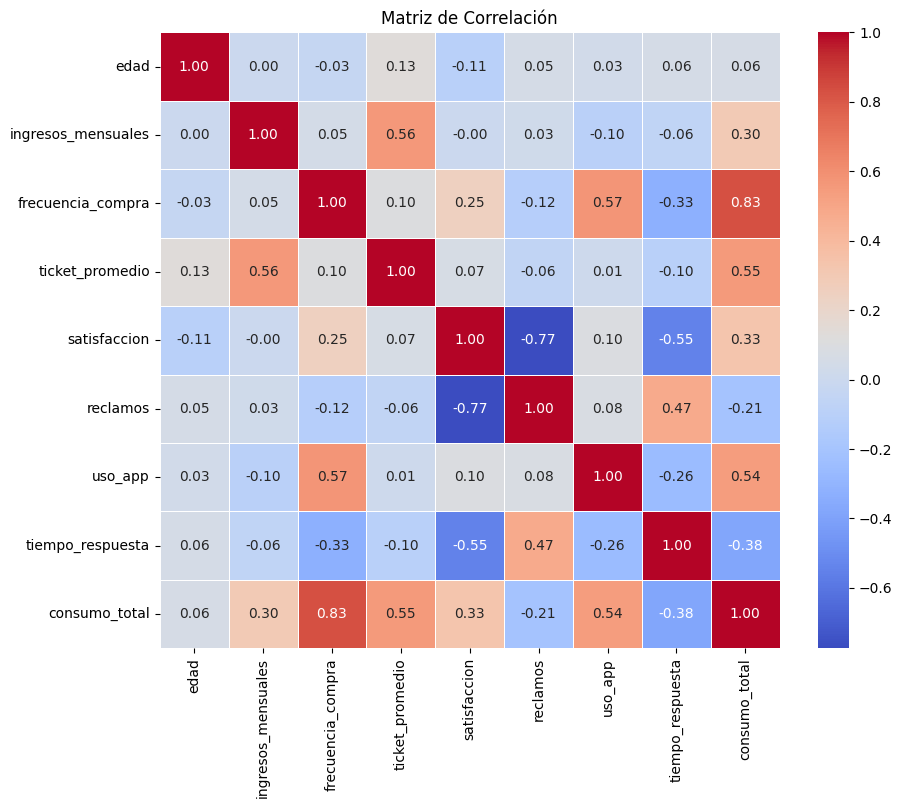

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación')
plt.show()